# Loan Default Prediction using Machine Learning

This project predicts whether a borrower will default on a loan using machine learning techniques. 
The dataset contains financial and demographic information about loan applicants.

Objectives:
• Analyze loan applicant data
• Build machine learning models
• Evaluate model performance
• Identify important features influencing loan default

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.metrics import roc_curve, roc_auc_score

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

In [3]:
df = pd.read_csv("../data/Raw/loan.csv")


C:\Users\Rudra\AppData\Local\Temp\ipykernel_21116\1818405376.py:1: DtypeWarning: Columns (47) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/Raw/loan.csv")


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39717 entries, 0 to 39716
Columns: 111 entries, id to total_il_high_credit_limit
dtypes: float64(74), int64(13), object(24)
memory usage: 33.6+ MB


In [5]:
df.isnull().sum()

id                                0
member_id                         0
loan_amnt                         0
funded_amnt                       0
funded_amnt_inv                   0
                              ...  
tax_liens                        39
tot_hi_cred_lim               39717
total_bal_ex_mort             39717
total_bc_limit                39717
total_il_high_credit_limit    39717
Length: 111, dtype: int64

In [6]:
df = df[df['loan_status'].isin(['Fully Paid','Charged Off'])]

df['loan_status'] = df['loan_status'].map({
    'Fully Paid':0,
    'Charged Off':1
})

In [7]:
drop_cols = [
'id','member_id','url','desc','title','zip_code',
'issue_d','last_pymnt_d','next_pymnt_d','last_credit_pull_d'
]

df.drop(columns=drop_cols, inplace=True, errors='ignore')

In [8]:
leakage_cols = [
    'total_pymnt',
    'total_pymnt_inv',
    'total_rec_prncp',
    'total_rec_int',
    'total_rec_late_fee',
    'recoveries',
    'collection_recovery_fee',
    'last_pymnt_amnt',
    'out_prncp',
    'out_prncp_inv'
]

df = df.drop(columns=leakage_cols, errors='ignore')

In [9]:
for col in df.select_dtypes(include=np.number).columns:
    if df[col].isnull().all():
        df[col] = df[col].fillna(0)
    else:
        df[col] = df[col].fillna(df[col].median())

for col in df.select_dtypes(include='object').columns:
    if df[col].isnull().all():
        df[col] = df[col].fillna("Unknown")
    else:
        df[col] = df[col].fillna(df[col].mode()[0])

In [10]:
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

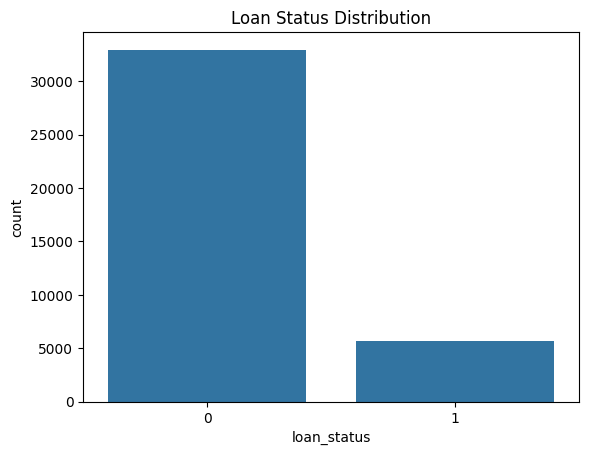

In [11]:
sns.countplot(x='loan_status',data=df)
plt.title("Loan Status Distribution")
plt.show()

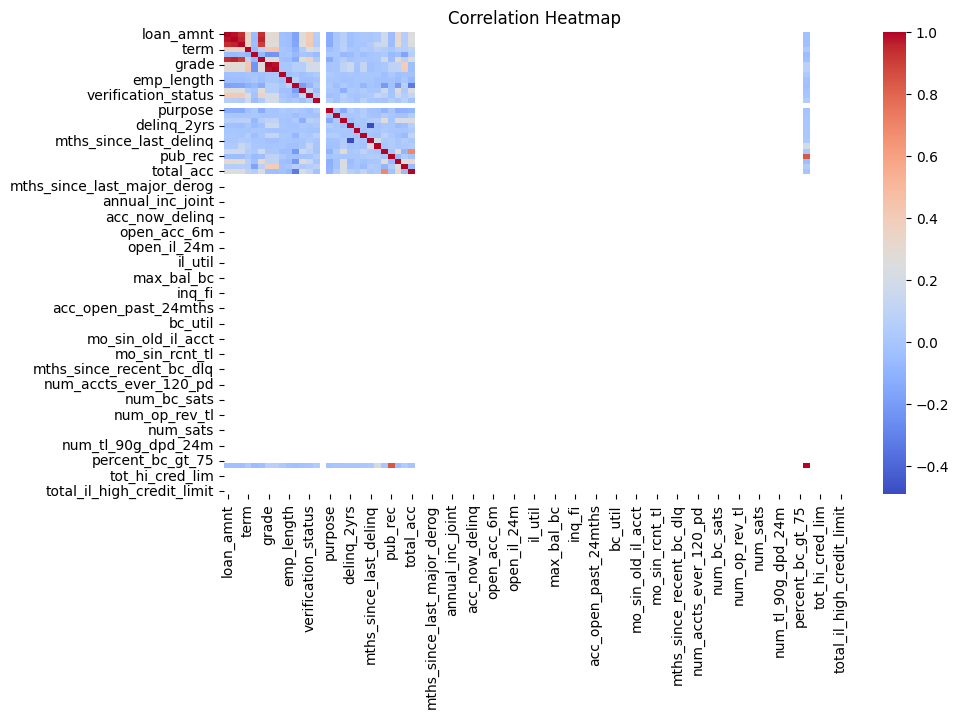

In [12]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [13]:
X = df.drop("loan_status", axis=1)
y = df["loan_status"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [14]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [15]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_train, y_train = sm.fit_resample(X_train, y_train)

In [16]:
RandomForestClassifier(class_weight='balanced')


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [17]:
DecisionTreeClassifier(class_weight='balanced')

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [18]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "KNN": KNeighborsClassifier()
}

In [19]:
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    })

In [20]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="Recall", ascending=False)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.660316,0.246096,0.644444,0.356178
3,KNN,0.613790,0.193591,0.520889,0.282274
1,Decision Tree,0.758165,0.214781,0.248000,0.230198
2,Random Forest,0.837092,0.287097,0.079111,0.124042


In [21]:
best_model_name = results_df.iloc[0]["Model"]
print("Best Model:", best_model_name)

Best Model: Logistic Regression


In [22]:
lr = LogisticRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
result_lr = []
result_lr.append({
        "Model": LogisticRegression.__name__,
        "Accuracy": accuracy_score(y_test, y_pred_lr),
        "Precision": precision_score(y_test, y_pred_lr),
        "Recall": recall_score(y_test, y_pred_lr),
        "F1 Score": f1_score(y_test, y_pred_lr)
    })
results_lr = pd.DataFrame(result_lr)
results_lr


,Model,Accuracy,Precision,Recall,F1 Score
0,LogisticRegression,0.660316,0.246096,0.644444,0.356178


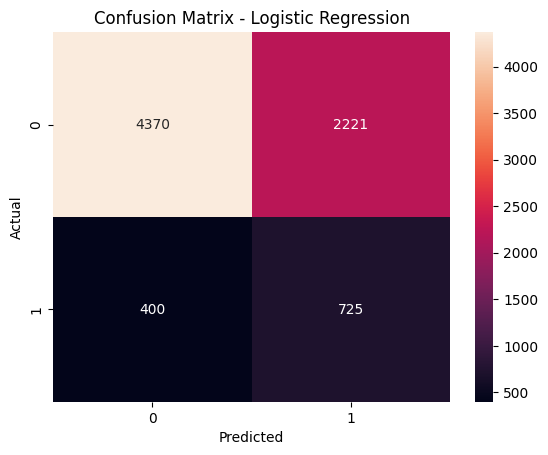

In [23]:
cm = confusion_matrix(y_test, y_pred_lr)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

Multiple machine learning models, including Logistic Regression, Decision Tree, K-Nearest Neighbors (KNN), and Random Forest, were evaluated for predicting loan default risk. Each model was trained and tested using the same dataset and assessed using accuracy, precision, recall, F1-score, and ROC-AUC to ensure a fair comparison.

Initially, most models achieved high accuracy, particularly Random Forest and Logistic Regression, both exceeding 85%. However, further analysis revealed that these models performed poorly in identifying defaulters due to class imbalance, as indicated by extremely low recall values.

To address this issue, class balancing techniques were applied using SMOTE. After balancing, all models were re-evaluated. Logistic Regression showed a significant improvement in recall, achieving the highest recall among all models, along with a balanced F1-score and consistent ROC-AUC performance. KNN also showed moderate improvement, while Decision Tree provided limited gains. Random Forest, despite maintaining relatively high accuracy, continued to exhibit low recall, making it less effective in identifying high-risk borrowers.

Since loan default prediction is a high-risk financial problem where failing to identify defaulters can lead to significant losses, recall was prioritized as the key evaluation metric. Based on this criterion, Logistic Regression was selected as the final model, as it demonstrated the best ability to correctly identify defaulters while maintaining reasonable overall performance.

Therefore, Logistic Regression was finalized for further deployment and integration into the application.

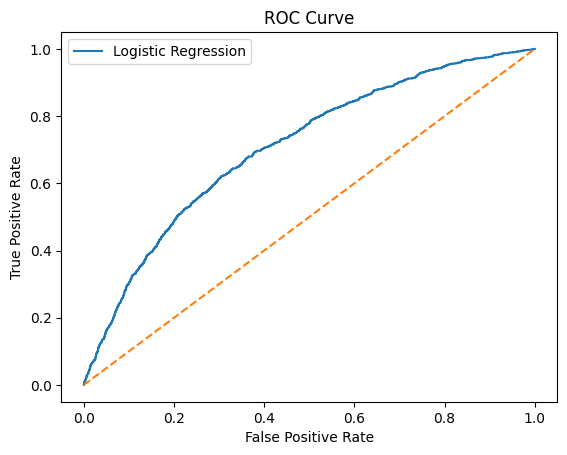

AUC Score: 0.7075183330804632


In [24]:


y_prob_lr = lr.predict_proba(X_test)

fpr, tpr, _ = roc_curve(y_test, y_prob_lr[:,1])

plt.plot(fpr, tpr, label="Logistic Regression")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

# AUC
auc = roc_auc_score(y_test, y_prob_lr[:,1])
print("AUC Score:", auc)

In [25]:
importance = pd.Series(
    lr.coef_[0],
    index=X.columns
).sort_values(key=abs, ascending=False)

top_features = importance.head(15)
print(top_features)

funded_amnt        0.577873
sub_grade          0.567202
annual_inc        -0.493604
funded_amnt_inv   -0.483728
term               0.284395
grade             -0.180288
inq_last_6mths     0.140242
purpose            0.125425
int_rate          -0.117463
emp_title          0.110141
addr_state        -0.106138
installment       -0.089814
revol_util         0.088818
pub_rec            0.078286
dti                0.071691
dtype: float64


In [26]:
from joblib import dump

dump(lr, "../models/logistic_model.joblib")
dump(scaler, "../models/scaler.joblib")

['../models/scaler.joblib']